# **Ejercicio 4 — Frecuencias de n-gramas por clase**

Frecuencias de unigramas, bigramas y trigramas sobre `data/processed/tweets_procesado.csv`

In [16]:
from collections import Counter
import math

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)

RUTA = "../data/processed/tweets_procesado.csv"
df = pd.read_csv(RUTA)
df["tokens"] = df["tokens"].fillna("")

desastre = df.loc[df["target"] == 1, "tokens"]
no_desastre = df.loc[df["target"] == 0, "tokens"]

print(f"tweets de desastre real : {len(desastre):,}")
print(f"tweets que no lo son    : {len(no_desastre):,}")
print(f"total                   : {len(df):,}")

tweets de desastre real : 3,188
tweets que no lo son    : 4,297
total                   : 7,485


## **1. Conteos por tipo de n-grama**

In [17]:
def generar_ngramas(serie, n):
    '''Cuenta los n-gramas de una serie de tweets tokenizados.'''
    conteo = Counter()
    for texto in serie:
        tokens = texto.split()
        conteo.update(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))
    return conteo


def tabla_frecuencias(conteo, top=15):
    '''Convierte un Counter en un DataFrame con frecuencia y probabilidad.'''
    total = sum(conteo.values())
    filas = [{"ngrama": " ".join(g), "frecuencia": f, "probabilidad": f / total}
             for g, f in conteo.most_common(top)]
    return pd.DataFrame(filas)


ngramas = {}
for n in (1, 2, 3):
    ngramas[n] = {"desastre": generar_ngramas(desastre, n),
                  "no_desastre": generar_ngramas(no_desastre, n)}

resumen = []
for n in (1, 2, 3):
    for clase, conteo in ngramas[n].items():
        hapax = sum(1 for f in conteo.values() if f == 1)
        resumen.append({
            "n": n, "clase": clase,
            "total": sum(conteo.values()),
            "distintos": len(conteo),
            "aparecen_1_vez": hapax,
            "pct_1_vez": round(hapax / len(conteo) * 100, 1),
            "aparecen_5_o_mas": sum(1 for f in conteo.values() if f >= 5),
        })
pd.DataFrame(resumen)

,n,clase,total,distintos,aparecen_1_vez,pct_1_vez,aparecen_5_o_mas
0,1,desastre,28577,7019,4070,58.0,1270
1,1,no_desastre,34096,9129,5481,60.0,1468
2,2,desastre,25391,17954,15592,86.8,473
3,2,no_desastre,29800,25122,23147,92.1,308
4,3,desastre,22218,17195,15508,90.2,315
5,3,no_desastre,25605,22862,21728,95.0,200


## **2. Unigramas**

In [18]:
top_des = tabla_frecuencias(ngramas[1]["desastre"], 15)
top_no = tabla_frecuencias(ngramas[1]["no_desastre"], 15)

comparacion = pd.concat(
    [top_des.rename(columns={"ngrama": "palabra_desastre",
                             "frecuencia": "f_des", "probabilidad": "P_des"}),
     top_no.rename(columns={"ngrama": "palabra_no_desastre",
                            "frecuencia": "f_no", "probabilidad": "P_no"})],
    axis=1,
)
comparacion.round(5)

,palabra_desastre,f_des,P_des,palabra_no_desastre,f_no,P_no
0,fire,262,0.00917,like,254,0.00745
1,news,139,0.00486,get,185,0.00543
2,via,119,0.00416,new,171,0.00502
3,disaster,116,0.00406,would,147,0.00431
4,california,114,0.00399,one,139,0.00408
5,police,107,0.00374,body,119,0.00349
6,people,102,0.00357,day,102,0.00299
7,home,102,0.00357,time,102,0.00299
8,family,102,0.00357,video,101,0.00296
9,suicide,101,0.00353,via,98,0.00287


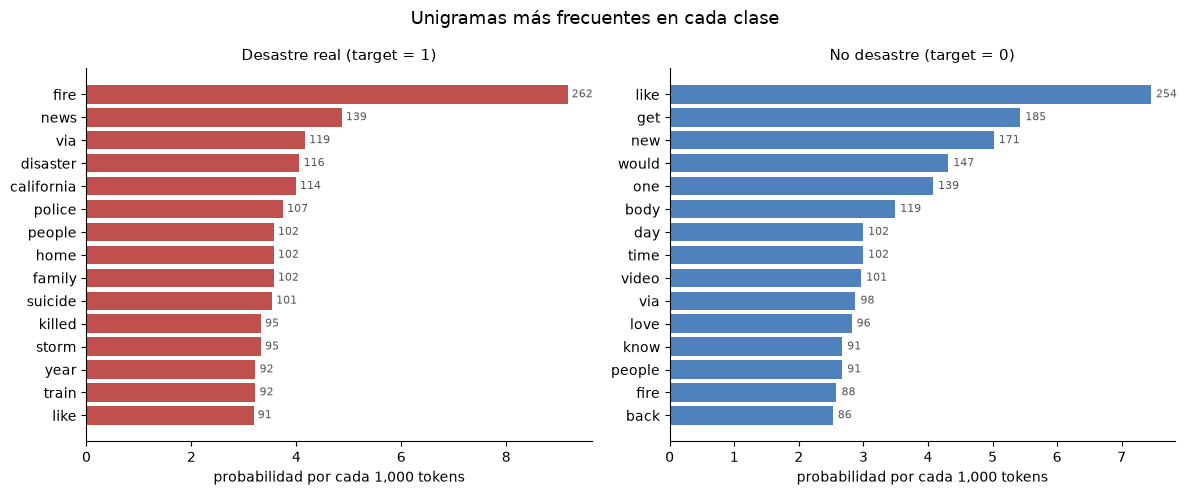

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False)
for ax, tabla, titulo, color in [
    (axes[0], top_des, "Desastre real (target = 1)", "#c0504d"),
    (axes[1], top_no, "No desastre (target = 0)", "#4f81bd"),
]:
    d = tabla.iloc[::-1]
    ax.barh(d["ngrama"], d["probabilidad"] * 1000, color=color)
    for y, (p, f) in enumerate(zip(d["probabilidad"] * 1000, d["frecuencia"])):
        ax.text(p + 0.08, y, f"{f}", va="center", fontsize=8, color="#555")
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("probabilidad por cada 1,000 tokens")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Unigramas más frecuentes en cada clase", fontsize=13)
plt.tight_layout()
plt.show()

`via` aparece en el top de las dos clases, y del lado de no desastre aparece `body`. La frecuencia
bruta no basta, entonces se mide cuánto separa cada palabra con el log-odds entre clases, filtrando
las que tienen menos de 10 apariciones.

## **3. Palabras que más discriminan**

In [20]:
FRECUENCIA_MINIMA = 10

conteo_d, conteo_n = ngramas[1]["desastre"], ngramas[1]["no_desastre"]
total_d, total_n = sum(conteo_d.values()), sum(conteo_n.values())
vocabulario = set(conteo_d) | set(conteo_n)
V = len(vocabulario)

filas = []
for g in vocabulario:
    f_d, f_n = conteo_d.get(g, 0), conteo_n.get(g, 0)
    if f_d + f_n < FRECUENCIA_MINIMA:
        continue
    p_d = (f_d + 1) / (total_d + V)
    p_n = (f_n + 1) / (total_n + V)
    filas.append({"palabra": g[0], "f_des": f_d, "f_no": f_n,
                  "total": f_d + f_n, "log_odds": math.log(p_d / p_n)})

discriminacion = pd.DataFrame(filas)
print(f"vocabulario conjunto            : {V:,} palabras")
print(f"compartidas por las dos clases  : {len(set(conteo_d) & set(conteo_n)):,} "
      f"({len(set(conteo_d) & set(conteo_n)) / V * 100:.1f}%)")
print(f"con al menos {FRECUENCIA_MINIMA} apariciones     : {len(discriminacion):,}")

pd.concat([
    discriminacion.nlargest(15, "log_odds").reset_index(drop=True)
        .rename(columns={"palabra": "hacia_desastre"}),
    discriminacion.nsmallest(15, "log_odds").reset_index(drop=True)
        .rename(columns={"palabra": "hacia_no_desastre"})[["hacia_no_desastre", "log_odds"]],
], axis=1).round(3)

vocabulario conjunto            : 12,735 palabras
compartidas por las dos clases  : 3,413 (26.8%)
con al menos 10 apariciones     : 1,321


,hacia_desastre,f_des,f_no,total,log_odds,hacia_no_desastre,log_odds
0,mh370,70,0,70,4.388,bag,-3.207
1,northern,61,0,61,4.253,ruin,-2.870
2,legionnaire,60,0,60,4.236,career,-2.708
3,debris,49,0,49,4.037,lmao,-2.708
4,severe,47,0,47,3.997,disney,-2.708
5,migrant,45,0,45,3.954,character,-2.583
6,hiroshima,91,1,92,3.954,ebay,-2.583
7,investigator,37,0,37,3.763,electrocute,-2.549
8,mosque,36,0,36,3.736,louis,-2.440
9,derailment,35,0,35,3.709,handbag,-2.400


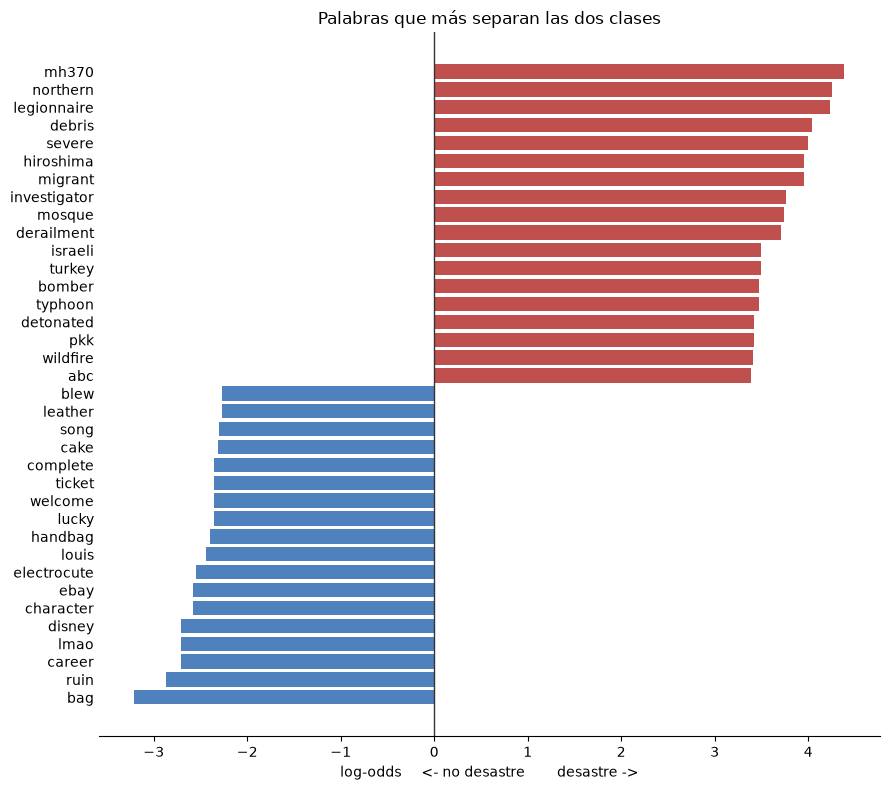

In [21]:
arriba = discriminacion.nlargest(18, "log_odds")
abajo = discriminacion.nsmallest(18, "log_odds")
d = pd.concat([abajo, arriba]).sort_values("log_odds")

fig, ax = plt.subplots(figsize=(9, 8))
colores = ["#4f81bd" if v < 0 else "#c0504d" for v in d["log_odds"]]
ax.barh(d["palabra"], d["log_odds"], color=colores)
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel("log-odds     <- no desastre        desastre ->")
ax.set_title("Palabras que más separan las dos clases", fontsize=12)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
plt.show()

Las de mayor log-odds son nombres de noticias concretas de 2015: `mh370` es el vuelo de Malaysia
Airlines, `legionnaire` el brote en Nueva York, `northern` los incendios de California y
`hiroshima` el aniversario del bombardeo.

In [22]:
discriminacion["magnitud"] = discriminacion["log_odds"].abs()
ambiguas = discriminacion[discriminacion["total"] >= 40].nsmallest(12, "magnitud")
ambiguas[["palabra", "f_des", "f_no", "total", "log_odds"]].round(3).reset_index(drop=True)

,palabra,f_des,f_no,total,log_odds
0,china,20,23,43,-0.008
1,said,24,27,51,0.012
2,weapon,41,46,87,0.013
3,fatality,35,39,74,0.020
4,plan,35,41,76,-0.029
5,first,50,59,109,-0.037
6,school,31,37,68,-0.046
7,could,40,48,88,-0.053
8,live,30,32,62,0.063
9,another,33,35,68,0.068


Palabras frecuentes que no separan nada, con `emergency` en 77 contra 81 y `fatality` en 35
contra 39.

## **4. Bigramas**

In [23]:
big_des = tabla_frecuencias(ngramas[2]["desastre"], 15)
big_no = tabla_frecuencias(ngramas[2]["no_desastre"], 15)

pd.concat([
    big_des.rename(columns={"ngrama": "bigrama_desastre",
                            "frecuencia": "f_des", "probabilidad": "P_des"}),
    big_no.rename(columns={"ngrama": "bigrama_no_desastre",
                           "frecuencia": "f_no", "probabilidad": "P_no"}),
], axis=1).round(5)

,bigrama_desastre,f_des,P_des,bigrama_no_desastre,f_no,P_no
0,suicide bomber,55,0.00217,body bag,49,0.00164
1,northern california,41,0.00161,cross body,39,0.00131
2,oil spill,38,0.00150,liked video,34,0.00114
3,california wildfire,35,0.00138,look like,32,0.00107
4,suicide bombing,33,0.00130,full read,28,0.00094
5,home razed,29,0.00114,feel like,25,0.00084
6,burning building,28,0.00110,body bagging,24,0.00081
7,severe thunderstorm,28,0.00110,quarantine offensive,21,0.00070
8,latest home,28,0.00110,offensive content,20,0.00067
9,razed northern,28,0.00110,content policy,20,0.00067


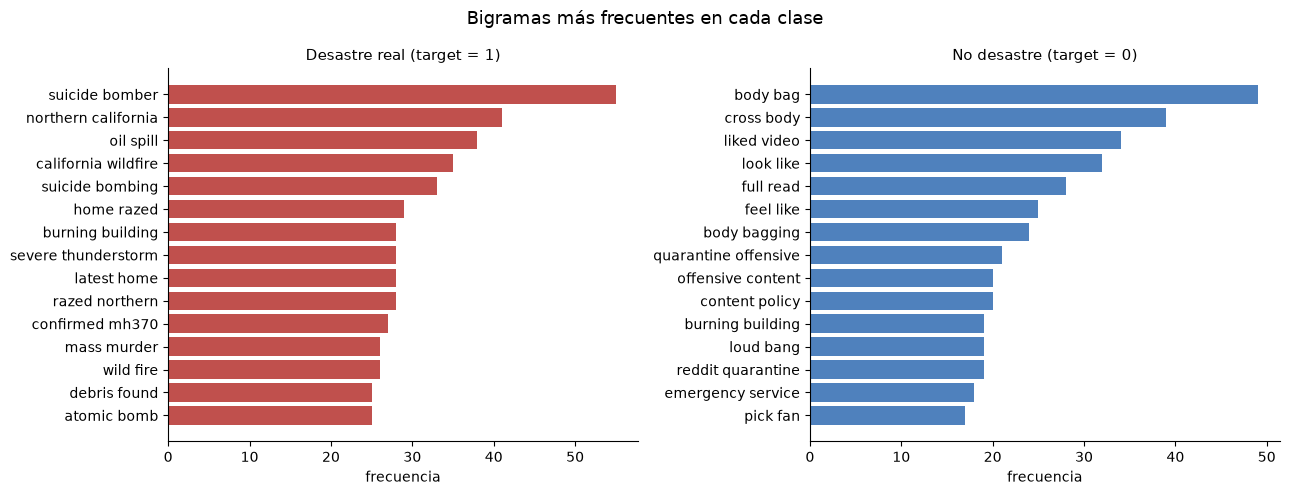

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, tabla, titulo, color in [
    (axes[0], big_des, "Desastre real (target = 1)", "#c0504d"),
    (axes[1], big_no, "No desastre (target = 0)", "#4f81bd"),
]:
    d = tabla.iloc[::-1]
    ax.barh(d["ngrama"], d["frecuencia"], color=color)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("frecuencia")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Bigramas más frecuentes en cada clase", fontsize=13)
plt.tight_layout()
plt.show()

El caso de `body`, que quedó pendiente en la sección 2:

In [25]:
for patron, etiqueta in [("body", "unigrama 'body'"), ("body bag", "bigrama 'body bag'")]:
    sub = df[df["tokens"].str.contains(patron, regex=False, na=False)]
    print(f"{etiqueta:22s}: {len(sub):4d} tweets | tasa de desastre {sub['target'].mean():.3f}")

print("\nEl mismo bigrama en las dos clases: 'burning building'")
sub = df[df["tokens"].str.contains("burning building", regex=False, na=False)]
print(f"  {len(sub)} tweets | por clase: {sub['target'].value_counts().to_dict()}")
for _, fila in sub.head(4).iterrows():
    print(f"    [target={fila['target']}] {fila['text'][:92]!r}")

unigrama 'body'       :  167 tweets | tasa de desastre 0.216
bigrama 'body bag'    :   79 tweets | tasa de desastre 0.076

El mismo bigrama en las dos clases: 'burning building'
  47 tweets | por clase: {1: 28, 0: 19}
    [target=0] '@SonofLiberty357 all illuminated by the brightly burning buildings all around the town!'
    [target=1] '@DougMartin17 Fireman Ed runs into burning buildings while others are running out Doug he de'
    [target=1] '@themagickidraps not upset with a rally upset with burning buildings businesses executing co'
    [target=1] '@_minimehh @cjoyner I must be overlooking the burning buildings? #BlackLivesMatter'


`body` sola tiene una tasa de desastre del 21.6% y `body bag` la baja al 7.6%. En cambio
`burning building` aparece en las dos clases, 28 contra 19.

## **5. Trigramas**

In [26]:
tri_des = tabla_frecuencias(ngramas[3]["desastre"], 15)
tri_no = tabla_frecuencias(ngramas[3]["no_desastre"], 15)

pd.concat([
    tri_des.rename(columns={"ngrama": "trigrama_desastre",
                            "frecuencia": "f_des", "probabilidad": "P_des"}),
    tri_no.rename(columns={"ngrama": "trigrama_no_desastre",
                           "frecuencia": "f_no", "probabilidad": "P_no"}),
], axis=1).round(5)

,trigrama_desastre,f_des,P_des,trigrama_no_desastre,f_no,P_no
0,northern california wildfire,29,0.00131,cross body bag,24,0.00094
1,latest home razed,28,0.00126,quarantine offensive content,20,0.00078
2,home razed northern,28,0.00126,reddit quarantine offensive,19,0.00074
3,razed northern california,27,0.00122,pick fan army,17,0.00066
4,family sue legionnaire,25,0.00113,reddit new content,16,0.00062
5,family affected fatal,25,0.00113,new content policy,16,0.00062
6,affected fatal outbreak,25,0.00113,china stock market,16,0.00062
7,suicide bomber detonated,25,0.00113,stock market crash,16,0.00062
8,severe thunderstorm warning,24,0.00108,full read ebay,15,0.00059
9,sue legionnaire family,24,0.00108,ignition knock detonation,15,0.00059


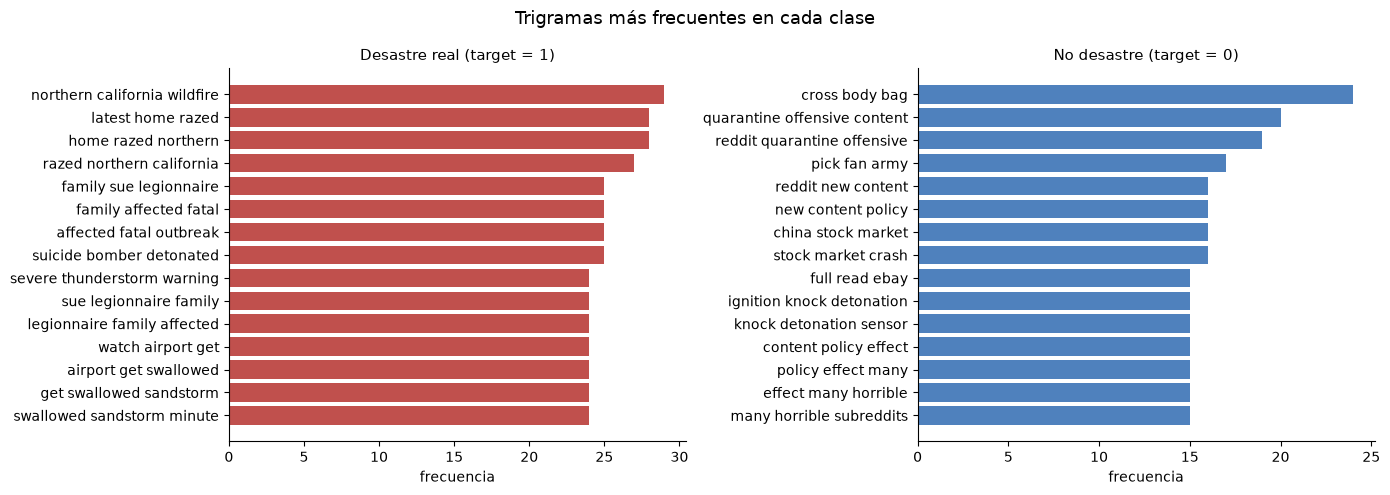

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tabla, titulo, color in [
    (axes[0], tri_des, "Desastre real (target = 1)", "#c0504d"),
    (axes[1], tri_no, "No desastre (target = 0)", "#4f81bd"),
]:
    d = tabla.iloc[::-1]
    ax.barh(d["ngrama"], d["frecuencia"], color=color)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("frecuencia")
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Trigramas más frecuentes en cada clase", fontsize=13)
plt.tight_layout()
plt.show()

In [28]:
sub = df[df["tokens"].str.contains("razed northern", regex=False, na=False)]
print(f"tweets que contienen 'razed northern': {len(sub)} | "
      f"por clase: {sub['target'].value_counts().to_dict()}\n")
for texto in sub["text"].head(4):
    print("   ", repr(texto[:100]))

tweets que contienen 'razed northern': 29 | por clase: {1: 29}

    'The Latest: More Homes Razed by Northern California Wildfire - ABC News http://t.co/AKnBtuyaef'
    'The Latest: More homes razed by Northern California wildfire: The latest on wildfires burning in Cal'
    'The Latest: More homes razed by Northern California wildfire - http://t.co/nTSwUAYEJI http://t.co/wg'
    'The Latest: More Homes Razed by Northern California Wildfire - ABC News http://t.co/ZBZc8905Gl'


`latest home razed`, `home razed northern` y `razed northern california` son ventanas solapadas de
un mismo titular de ABC News retuiteado 29 veces. Los conteos brutos están inflados por repetición
del mismo texto, entonces se mide en cuántos tweets distintos aparece cada n-grama.

In [29]:
def frecuencia_documento(serie, n):
    '''En cuantos tweets DISTINTOS aparece cada n-grama, sin contar repeticiones internas.'''
    conteo = Counter()
    for texto in serie:
        tokens = texto.split()
        conteo.update({tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)})
    return conteo


filas = []
doc_freq = {}
for n in (1, 2, 3):
    doc_freq[n] = frecuencia_documento(df["tokens"], n)
    total = len(doc_freq[n])
    filas.append({
        "n": n,
        "distintos": total,
        "en_1_solo_tweet": sum(1 for v in doc_freq[n].values() if v == 1),
        "en_2_o_mas": sum(1 for v in doc_freq[n].values() if v >= 2),
        "pct_en_2_o_mas": round(sum(1 for v in doc_freq[n].values() if v >= 2) / total * 100, 1),
        "en_5_o_mas": sum(1 for v in doc_freq[n].values() if v >= 5),
        "pct_en_5_o_mas": round(sum(1 for v in doc_freq[n].values() if v >= 5) / total * 100, 1),
    })
pd.DataFrame(filas)

,n,distintos,en_1_solo_tweet,en_2_o_mas,pct_en_2_o_mas,en_5_o_mas,pct_en_5_o_mas
0,1,12735,7389,5346,42.0,2358,18.5
1,2,41687,37109,4578,11.0,834,2.0
2,3,39323,36380,2943,7.5,564,1.4


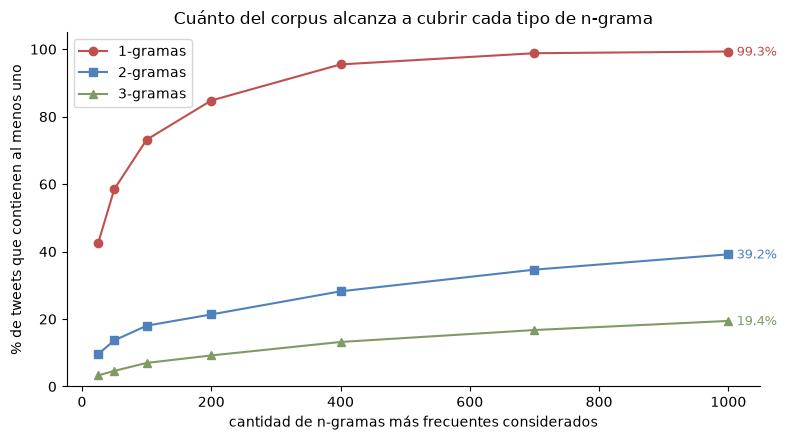

In [30]:
def cobertura(n, top_n):
    '''Porcentaje de tweets que contienen al menos uno de los top_n n-gramas mas comunes.'''
    top = {g for g, _ in doc_freq[n].most_common(top_n)}
    def toca(texto):
        tokens = texto.split()
        return any(tuple(tokens[i:i + n]) in top for i in range(len(tokens) - n + 1))
    return df["tokens"].map(toca).mean() * 100


tamanos = [25, 50, 100, 200, 400, 700, 1000]
curvas = {n: [cobertura(n, k) for k in tamanos] for n in (1, 2, 3)}

fig, ax = plt.subplots(figsize=(8, 4.5))
for n, color, marca in [(1, "#c0504d", "o"), (2, "#4f81bd", "s"), (3, "#7f9a65", "^")]:
    ax.plot(tamanos, curvas[n], marker=marca, color=color, label=f"{n}-gramas")
    ax.annotate(f"{curvas[n][-1]:.1f}%", (tamanos[-1], curvas[n][-1]),
                textcoords="offset points", xytext=(6, -3), fontsize=9, color=color)

ax.set_xlabel("cantidad de n-gramas más frecuentes considerados")
ax.set_ylabel("% de tweets que contienen al menos uno")
ax.set_title("Cuánto del corpus alcanza a cubrir cada tipo de n-grama", fontsize=12)
ax.set_ylim(0, 105)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

En frecuencia de documento, el 42% de los unigramas aparece en dos o más tweets distintos, contra
un 11% de los bigramas y un 7.5% de los trigramas. Tomando los 200 más comunes de cada tipo, los
unigramas cubren el 84.8% del corpus, los bigramas el 21.4% y los trigramas el 9.2%.

---

# **6. Conclusiones**

### **Palabras con mayor influencia esperada en el modelo**

Vocabulario de suceso, que es el que generaliza:

- `debris`, `derailment`, `wreckage`, `typhoon`, `outbreak`, `severe`
- `bomber`, `suicide`, `killed`, `storm`, `wildfire`, `disaster`, `fire`, `police`

Vocabulario que empuja hacia la clase de no desastre, igual de necesario porque el clasificador
necesita evidencia en las dos direcciones:

- `bag`, `handbag`, `ruin`, `cake`, `ebay`
- `lmao`, `disney`, `career`, `love`, `like`

Nombres de eventos puntuales, que hay que vigilar:

- `mh370`, `legionnaire`, `hiroshima`, `northern`
- Son las de mayor log-odds de todo el vocabulario, sin embargo corresponden a noticias de 2015, de
  tal forma que rendirían muy bien en la partición de prueba y fallarían ante un tweet actual.
- No se eliminan, no obstante conviene tenerlas presentes al interpretar la importancia de las
  variables en el ejercicio 6.

Palabras que **no** deberían pesar, aunque la intuición diga lo contrario:

- `emergency`, `fatality`, `weapon`, `school`, `china`, `first`
- Aparecen prácticamente igual en las dos clases.

### **¿Vale la pena probar bigramas o trigramas?**

Con los bigramas sí, en un papel de apoyo:

- Resuelven ambigüedades que el unigrama no puede resolver, y `body` contra `body bag` lo muestra,
  ya que la tasa de desastre pasa de 21.6% a 7.6%.
- Expresiones como `suicide bomber`, `oil spill` o `severe thunderstorm` nombran el evento completo.
- No obstante, solo el 11% aparece en dos o más tweets y los 200 más comunes cubren el 21.4% del
  corpus, entonces no reemplazan a los unigramas.
- La configuración a probar será una vez como unigrama y luego bigramas.

Con los trigramas no:

- Entre el 90% y el 95% aparece una sola vez, así que no hay nada que aprender de ellos.
- Los que sí se repiten resultaron ser ventanas solapadas de titulares retuiteados, o sea una
  noticia contada cuatro veces y no un patrón del lenguaje.